# Problema 1 - Mediciones de tiempo
Preparamos el entorno e importamos las librearias necesarias

In [21]:
%pip install -q matplotlib seaborn scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import os
import sys
import time
import random
import numpy as np
import scipy as sp
import seaborn as sns
from matplotlib import pyplot as plt

# Importamos módulos desde el directorio actual y su padre
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(current_dir)
sys.path.append(parent_dir)

# Importamos la función a probar
from problema_1_pesada import buscar_moneda_falsa

# Establecemos semillas para la reproducibilidad de los resultados
random.seed(12345)
np.random.seed(12345)
sns.set_theme(style="whitegrid")

## Generación de datos para las mediciones y gráficos
Para cada tamaño $n$, generamos un arreglo de monedas con pesos:
- 10 para monedas reales
- 9 para una única moneda falsa en posición aleatoria

Para simular fielmente el escenario del problema, en cada instancia se genera un arreglo numérico y se ubica una única moneda defectuosa (peso 9) en un índice aleatorio; el resto de monedas tienen peso 10.

Los tamaños de entrada varían linealmente desde 1.000 hasta 100.000 elementos, distribuidos uniformemente en 20 puntos de medición.

En cada tamaño se registran dos variables:
- tiempo de ejecución promedio
- cantidad de pesadas


In [23]:
def generar_monedas(n: int):
    monedas = [10] * n
    idx_falsa = random.randrange(n)
    monedas[idx_falsa] = 9
    return monedas, idx_falsa

# 20 puntos equiespaciados entre 1.000 y 100.000
x = np.linspace(1_000, 100_000, 20).astype(int)
runs_por_tamanio = 10

tiempos_ms = []
pesadas = []
aciertos = []

for n in x:
    tiempos_n = []
    pesadas_n = []
    aciertos_n = []

    for _ in range(runs_por_tamanio):
        monedas, idx_esperado = generar_monedas(int(n))

        t0 = time.perf_counter()
        idx_obtenido, cant_pesadas = buscar_moneda_falsa(monedas)
        t1 = time.perf_counter()

        tiempos_n.append((t1 - t0) * 1000.0)
        pesadas_n.append(cant_pesadas)
        aciertos_n.append(idx_obtenido == idx_esperado)

    tiempos_ms.append(float(np.mean(tiempos_n)))
    pesadas.append(float(np.mean(pesadas_n)))
    aciertos.append(float(np.mean(aciertos_n)))

results_tiempo = {int(n): t for n, t in zip(x, tiempos_ms)}
results_pesadas = {int(n): p for n, p in zip(x, pesadas)}

print(f"Acierto promedio total: {np.mean(aciertos) * 100:.2f}%")

Acierto promedio total: 100.00%


c_1 = 4.76105068729e-05, c_2 = 0.0981707971252
Error cuadrático total (tiempo): 0.180919653538


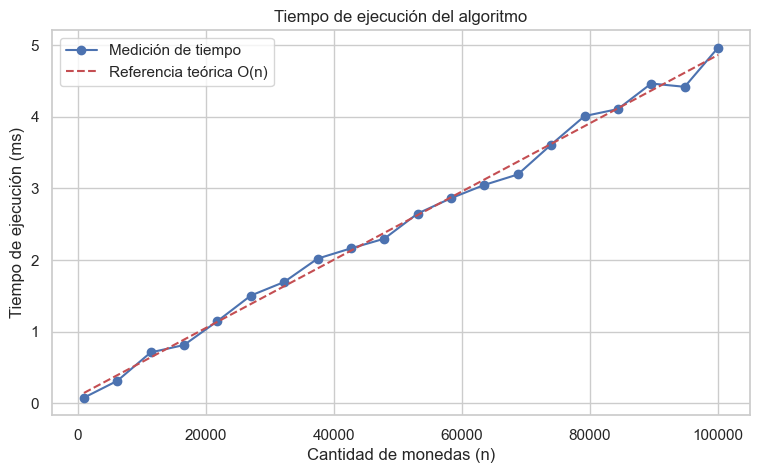

In [24]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f_tiempo = lambda x, c1, c2: c1 * x + c2
c_t, _ = sp.optimize.curve_fit(f_tiempo, x, [results_tiempo[n] for n in x])
r_t = np.sum((c_t[0] * x + c_t[1] - [results_tiempo[n] for n in x])**2)

print(f"c_1 = {c_t[0]:.12g}, c_2 = {c_t[1]:.12g}")
print(f"Error cuadrático total (tiempo): {r_t:.12g}")

ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, [results_tiempo[n] for n in x], "o-", label="Medición de tiempo")
ax.plot(x, [c_t[0] * n + c_t[1] for n in x], "r--", label="Referencia teórica O(n)")
ax.set_title("Tiempo de ejecución del algoritmo")
ax.set_xlabel("Cantidad de monedas (n)")
ax.set_ylabel("Tiempo de ejecución (ms)")
ax.legend()

c_1 = 0.986538177392, c_2 = 0.338074126305
Error cuadrático total (pesadas): 0.499126951633


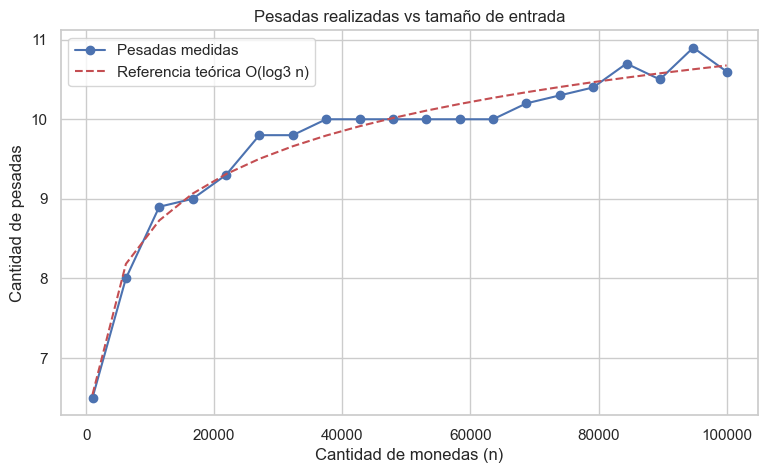

In [25]:
# Ajuste logarítmico para pesadas: c1*log3(n) + c2
f_pesadas = lambda x, c1, c2: c1 * (np.log(x) / np.log(3)) + c2
c_p, _ = sp.optimize.curve_fit(f_pesadas, x, [results_pesadas[n] for n in x])
r_p = np.sum((f_pesadas(x, c_p[0], c_p[1]) - [results_pesadas[n] for n in x])**2)

print(f"c_1 = {c_p[0]:.12g}, c_2 = {c_p[1]:.12g}")
print(f"Error cuadrático total (pesadas): {r_p:.12g}")

ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, [results_pesadas[n] for n in x], "o-", label="Pesadas medidas")
ax.plot(x, [f_pesadas(n, c_p[0], c_p[1]) for n in x], "r--", label="Referencia teórica O(log3 n)")
ax.set_title("Pesadas realizadas vs tamaño de entrada")
ax.set_xlabel("Cantidad de monedas (n)")
ax.set_ylabel("Cantidad de pesadas")
ax.legend()

Text(0, 0.5, 'Error absoluto (ms)')

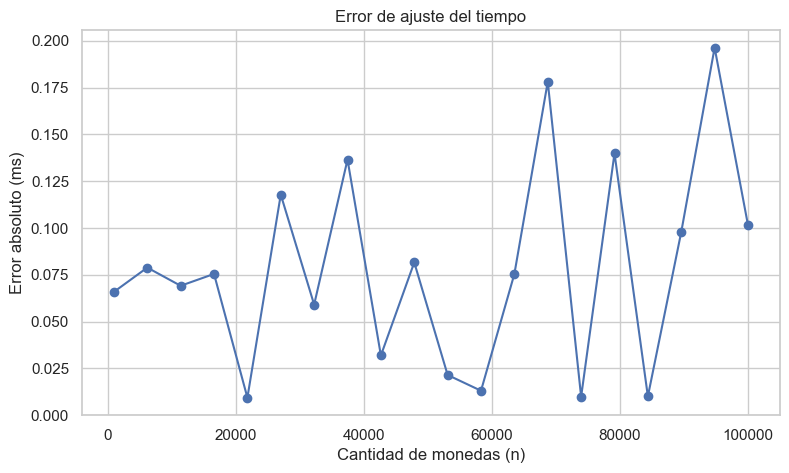

In [26]:
ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
errors_tiempo = [np.abs(c_t[0] * n + c_t[1] - results_tiempo[n]) for n in x]
ax.plot(x, errors_tiempo, "o-")
ax.set_title("Error de ajuste del tiempo")
ax.set_xlabel("Cantidad de monedas (n)")
ax.set_ylabel("Error absoluto (ms)")

Text(0, 0.5, 'Error absoluto (pesadas)')

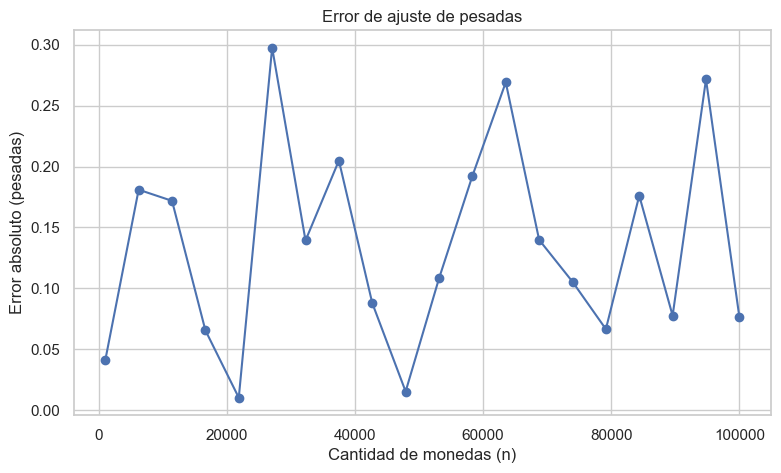

In [27]:
ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
errors_pesadas = [np.abs(f_pesadas(n, c_p[0], c_p[1]) - results_pesadas[n]) for n in x]
ax.plot(x, errors_pesadas, "o-")
ax.set_title("Error de ajuste de pesadas")
ax.set_xlabel("Cantidad de monedas (n)")
ax.set_ylabel("Error absoluto (pesadas)")